In [1]:
import os
# Disable tokenizers parallelism
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

In [2]:
!pip install datasets evaluate transformers[sentencepiece]
!pip install accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 13.2 MB/s eta 0:00:00
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.2.1
    Uninstalling accelerate-1.2.1:
      Successfully uninstalled accelerate-1.2.1


In [3]:
import pandas as pd
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
from torch.cuda import amp
from transformers import AutoModel, AutoTokenizer,AutoConfig
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,f1_score
import torch
import warnings
import random
warnings.filterwarnings('ignore')
from collections import defaultdict
import torch.nn as nn
from transformers import get_scheduler
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
from collections import defaultdict
import gc
gc.enable()


In [4]:
def set_random_seed(random_seed):
    random.seed(random_seed)
    np.random.seed(random_seed)
    os.environ["PYTHONHASHSEED"] = str(random_seed)

    torch.manual_seed(random_seed)
    torch.cuda.manual_seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)

    torch.backends.cudnn.deterministic = True

In [5]:
df = pd.read_csv("/kaggle/input/bengali-pharmaceutical-reviews/LargePharmaVal.csv")

In [6]:
df

,Reviews,category,Label,Length,Word Count
0,চকলেট নিয়ে খুব হতাশ। এক্সপায়ার ডেট শেষ আর অত...,Random/Misc,1,66,11
1,পঁচিশটা অর্ডার করেছিলাম পেয়েছি পঞ্চাশটা সাথে ...,medical_kits,4,183,32
2,সুন্দর প্যাকেজিং করে দিয়েছে! ১০০% অরিজিনাল প্...,womens_item,5,110,15
3,আমি কেন অনলাইনে প্রডাক্ট ক্রয় করলাম ভাই? গ্লোব...,medicines,2,107,18
4,ডেলিভারি একটু দেরি হলেও মাল ভালো। শ্যাম্পু প্র...,womens_item,4,92,15
...,...,...,...,...,...
9510,একদম নিম্ন মানের নেবুলাইজার দিয়ে ঠকালেন। মার্...,medical_kits,1,64,11
9511,"প্রথম কথা, এটা আইসক্রিম ফ্লেভার না, মেনথল/মিন্...",adult_items,1,375,61
9512,😭😭 কি মারাত্মক মাস্ক! মানসম্মত না আর সাইজ ছোট ...,medical_kits,1,53,10
9513,যা ছিল আমার ইচ্ছায় মোটামুটি সব দিয়েছেন সেলার। ...,medicines,4,135,22


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9515 entries, 0 to 9514
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Reviews     9515 non-null   object
 1   category    9515 non-null   object
 2   Label       9515 non-null   int64 
 3   Length      9515 non-null   int64 
 4   Word Count  9515 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 371.8+ KB


In [8]:
df.Label.value_counts()

Label
5    2238
1    2199
4    1989
2    1563
3    1526
Name: count, dtype: int64

In [9]:
df['Label'] = df['Label'].map({1: 0, 2: 1, 3: 2, 4: 3, 5: 4})
print(df['Label'].value_counts()) 

Label
4    2238
0    2199
3    1989
1    1563
2    1526
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

# Step 1: Split the data into train and temp (test + validation) sets
train_data, temp_data = train_test_split(df, test_size=0.3, stratify=df['Label'], random_state=1)

# Step 2: Split the temp set into validation and test sets (10% validation, 20% test)
val_data, test_data = train_test_split(temp_data, test_size=2/3, stratify=temp_data['Label'], random_state=1)

In [11]:
train_data.to_csv("/kaggle/working/train_data.csv", index=False)
val_data.to_csv("/kaggle/working/val_data.csv", index=False)
test_data.to_csv("/kaggle/working/test_data.csv", index=False)

In [12]:
train_data.shape, val_data.shape

((6660, 5), (951, 5))

In [13]:
with pd.option_context('display.max_colwidth',0):
    display(train_data.sample(n=10))

,Reviews,category,Label,Length,Word Count
4487,ক্যাপসুল থেকে সিরাপ সব জিনিসের দাম এভাবে বাড়তি রাখছে তারা। এগুলো কেমন কথা?,Random/Misc,1,74,13
8711,পানির সাথে মেশাতেই কিছুটা সাইড এফেক্ট দেখা দিচ্ছে ওষুধের। তাই আমার শরীর জ্বালাপোড়া করে। দাম একটু কম রেখেছে এটা ভালো লেগেছে যদিও। তবে এক কথা বলে অন্যটা দেয়া ঠিক না।,medicines,2,164,30
7269,"মাস্ক গুলো পরে যখন ফু দিলাম তখন বাতাস বের হয়ে যাচ্ছে, এগুলো ভাইরাস কে আসলেই প্রতিরোধ করতে পারবে কিনা আমার সন্দেহ আছে। দেখি কয়দিন যায়।",medical_kits,2,136,25
2748,"প্যাকিং ভালো, যথাসময়ে হাতে পেলাম। ব্যবহার করি রেগুলার দেখা যাচ্ছে ভালো হবে। আশাবাদী গুনগত মান ঠিক থাকবে। ১০০% ভরসা আছে, আমি প্রায় সময় পণ্য কিনে থাকি। সেলারকে ধন্যবাদ।",womens_item,4,166,28
7298,এই চকলেট নিয়ে মিক্স ফিলিংস। এত দামি মাল এত খারাপ কেন,Random/Misc,1,53,11
7316,"মাশাআল্লাহ সেরা কোয়ালিটি 😊। চুল পড়া কমেছে অনেক, কম্বো অফার ছিল দারুণ। সেলার অসাধারণ সার্ভিস দিয়েছেন 🥰",womens_item,4,104,17
5928,ক্যালসিয়াম ট্যাবলেট গুলো ডেট ফেল। এমন জিনিস পাঠিয়ে আমার ক্ষতি করলেন ভাই।,Random/Misc,1,72,12
2755,প্রোডাক্ট টি 100% বাংলা মাল। বার কোড স্কান করলেই বুঝবেন। 180 টাকার জিনিস 250 টাকা বিক্রি করছে।\nপ্রোডাক্ট টি 100% ডুপ্লিকেট। নকল প্রডাক্ট কিনে প্রতারিত হবেন না।,womens_item,0,160,27
1562,এই সাপ্লিমেন্ট নিয়ে মিক্স ফিলিংস। মনে হয় পুরাতন স্টক,body_fitness,1,54,9
3694,কি বলার আছে নিজেই দেখুন। তাকে আমি কি অর্ডার করেছি আর সে কি দিয়েছে। হলুদ রঙের মাস্ক কেউ পড়ে? শালা আবুল!,medical_kits,1,102,21


In [14]:
with pd.option_context('display.max_colwidth',0):
    display(val_data.sample(n=10))

,Reviews,category,Label,Length,Word Count
5705,মাস্কটি মোটামুটি ভালো বলবো। দাম হিসাবে আহামরি কিছু না। তবে সবার রিভিউ মোতাবেক আশানুরূপ নয়।,medical_kits,2,91,15
1086,খুব বাজে অভিজ্ঞতা ৩ টাকার শ্যাম্পু ৪ টাকা করে নিল। এটা জালিয়াতি ছাড়া আর কি?,womens_item,0,76,15
5984,ডিজিটাল থার্মোমিটার হলেও কোয়ালিটি একদম নিম্নমানের। কোন কাজের না। দেখেই মনে হয়েছিল ভালো হবে না। ১ মাস হবার আগেই নষ্ট হয়েগেছে।,medical_kits,0,125,21
4918,এর আগে এখান থেকে অনেক কিছু কিনেছি আর ডেলিভারি ম্যান ও খুব ভালো 😘 ছিল কিন্তু এই বার একটা বেয়াদব ছেলে এসেছিল খুবই কষ্ট পেয়েছি তার ব্যবহারে 🥺,womens_item,2,142,28
9357,কি সর্বনাশ করলাম নেবুলাইজার কিনে! ফেক ডিসকাউন্ট দেখিয়েছে ☹️☹️ ভুল জায়গায় ডেলিভারি দিয়েছে রিটার্ন করতে চাই,medical_kits,0,109,16
754,প্রোডাক্ট হিসাবে খুবই ভালো। মাস্কের কোয়ালিটিও অন্য যেকোন সার্জিক্যাল মাস্ক থেকে বেটার। নিশ্চিন্ত মনে কিনতে পারেন। সাথে একটা গিফট হিসাবে বাচ্চাদের জন্য মাস্ক \nদেয়া হয়েছিল । ধন্যবাদ সেলারকে ❤️,medical_kits,4,190,29
3327,"শ্যাম্পু সাথে লোশন ফ্রি, অনেক ভালো লেগেছে, এই প্রথম কিনলাম, ভালো হলে আবার নিবো, \nআমি অনেক খুশি এবং ডেলিভারিও খুব তাড়াতাড়ি পেয়েছি \nডেলিভারি পেতে কোনো সমস্যা হয়নি, অনেক যত্নের সাথে গ্যাসের ক্যাপসুলগুলো\nহাতে পৌছে দিয়েছে, ডেলিভারি ম্যান খুব ভালো 😍😍",medicines,4,247,40
2541,ডায়াপার দেখে মন খারাপ হয়ে গেল। সিল ভাঙ্গা সাইজ ছোট দিয়েছে 😠😠,baby_items,0,63,12
2422,প্যারাসুট শ্যাম্পু দেখে ভাবলাম প্যারাসুট যেহেতু তেলের জন্য ভালো শ্যাম্পুর ক্ষেত্রেও কোয়ালিটি ঠিক থাকবে। সত্যিই তাই প্রথমবার ধোঁয়াতে চুল অনেক সফট হয়েছে। মাথা ঝরঝরে পরিষ্কার হয়।\nএখন থেকে এটাই কন্টিনিউ করব ইনশাল্লাহ। কমপ্লিট সলিউশন ফর হেয়ার। অনেক অনেক শুকরিয়া ভাই। আপনাদের দোকানে বেশি বেশি কাস্টমার অর্ডার করে সঠিক পণ্য বুঝে নিক এই দুয়া করি।,womens_item,4,342,54
416,খুব ভাল প্রডাক্ট হতে পারত তবে পানি পরিবর্তনে ক্ষেত্রে অনেক ঝামেলা পোহাতে হয়। সাথে দেয়া ইলেক্টিক ক্যাবলটি একদম সুবিধাজনক না।,medical_kits,1,123,20


In [15]:
# checkpoint = "csebuetnlp/banglabert" "sagorsarker/bangla-bert-base" "csebuetnlp/banglabert_large"
class Config:
    NUM_EPOCHS = 15
    BATCH_SIZE = 32
    MODEL_PATH = "csebuetnlp/banglabert"
    LR = 2e-5
    DROPOUT = 0.3
    NUM_CLASSES = 5
    SEED = 1
    MAX_LEN = 100
    DEVICE =  "cuda" if torch.cuda.is_available() else "cpu"

config  = Config()

In [16]:
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_PATH)

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

<Axes: ylabel='Count'>

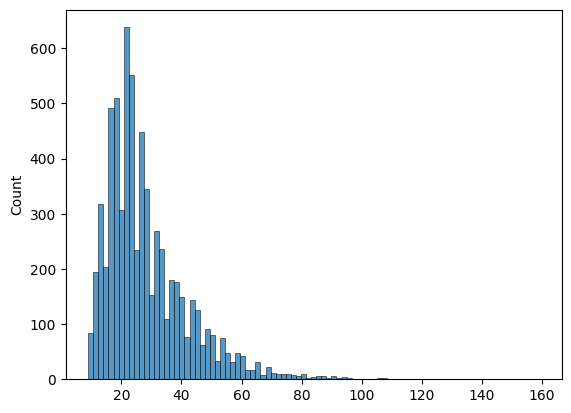

In [17]:
token_counts = []

for _, row in train_data.iterrows():
    text = str(row["Reviews"])  # Ensure the text is converted to a string
    token_count = len(tokenizer.encode(
        text,
        max_length=512,
        truncation=True
    ))
    token_counts.append(token_count)

sns.histplot(token_counts)

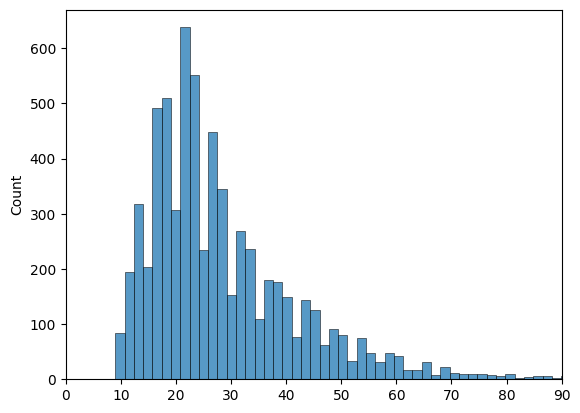

In [18]:
sns.histplot(token_counts)
plt.xlim([0, 90]);

<Axes: ylabel='Count'>

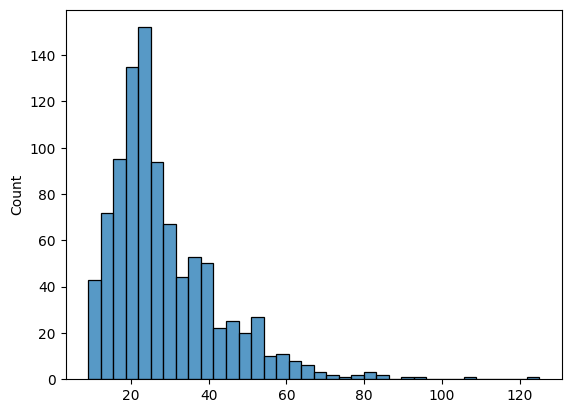

In [19]:
token_counts = []

for _, row in val_data.iterrows():
    text = str(row["Reviews"])  # Ensure the text is converted to a string
    token_count = len(tokenizer.encode(
        text,
        max_length=512,
        truncation=True
    ))
    token_counts.append(token_count)

sns.histplot(token_counts)


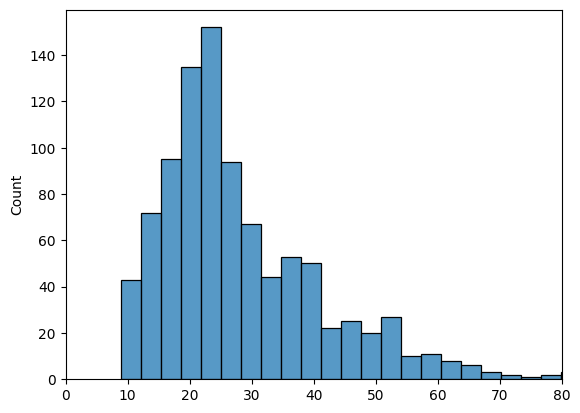

In [20]:
sns.histplot(token_counts)
plt.xlim([0, 80]);

In [21]:
class ClassifierDataset(Dataset):
    def __init__(self, df,tokenizer):
        super(ClassifierDataset, self).__init__()
        self.df = df 
        self.labels = torch.tensor(df.Label.values, dtype=torch.long)
        self.tokenizer = tokenizer
        self.max_length = config.MAX_LEN

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        text = str(self.df.iloc[index]["Reviews"])
        inputs = self.tokenizer(
            text,
            padding=True, 
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )
        input_ids = inputs["input_ids"].squeeze(0)
        attention_mask = inputs["attention_mask"].squeeze(0)
        labels = self.labels[index]

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }


In [22]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [23]:
class Engine:
    def __init__(self, model, optimizer,scheduler = None):
        self.model = model
        self.optimizer = optimizer
        self.scheduler = scheduler
        
    @staticmethod
    def loss_fn(target, pred):
        loss_fct = nn.CrossEntropyLoss()
        loss = loss_fct(pred,target)
        return loss
    
    @staticmethod
    def compute_metrics(labels, pred):
        y_true = labels.cpu().numpy()
        pred = pred.cpu().numpy()
        y_pred = np.argmax(pred, axis = -1)
        f1 = f1_score(y_true, y_pred, average='weighted')
        return f1
        
    def train(self, train_dataloader,scaler,num_training_steps):
        self.model.train()
        total_training_loss = 0.0
        progress_bar = tqdm(range(num_training_steps))
        for data in train_dataloader:
            input_ids = data["input_ids"].to(config.DEVICE)
            attention_mask = data["attention_mask"].to(config.DEVICE)            
            target = data["labels"].to(config.DEVICE)
            self.optimizer.zero_grad()
            
            with amp.autocast():
                pred = self.model(input_ids, attention_mask)
                loss = self.loss_fn(target,pred)
                
            total_training_loss += loss.item()
            scaler.scale(loss).backward()
            scaler.step(self.optimizer)
            scaler.update()
            if self.scheduler:
                self.scheduler.step()
            progress_bar.update(1)
                
        return total_training_loss / len(train_dataloader)
    
    def evaluate(self,eval_dataloader):
        self.model.eval()
        val_loss = 0
        score = 0.0
        with torch.no_grad():
            for data in tqdm(eval_dataloader):
                input_ids = data["input_ids"].to(config.DEVICE)  
                attention_mask = data["attention_mask"].to(config.DEVICE)              
                target = data["labels"].to(config.DEVICE)  
                
                pred = self.model(input_ids, attention_mask)
                loss = self.loss_fn(target,pred)
                val_loss += loss.item()
                batch_score = self.compute_metrics(target,pred)
                score+= batch_score
             
            score = score / len(eval_dataloader)
            val_loss = val_loss / len(eval_dataloader)
        
        return score, val_loss

In [24]:
# import torch
# import torch.nn as nn
# from transformers import AutoModel, AutoConfig

# class ClassifierModel(nn.Module):
#     def __init__(self):
#         super(ClassifierModel, self).__init__()
#         self.model_config = AutoConfig.from_pretrained(config.MODEL_PATH)
#         self.model = AutoModel.from_pretrained(config.MODEL_PATH, config=self.model_config)
        
#         # Multi-head self attention layer
#         self.attention = nn.MultiheadAttention(
#             embed_dim=self.model_config.hidden_size,
#             num_heads=8,
#             dropout=0.1,
#             batch_first=True
#         )
        
#         # Dense layers
#         self.dense1 = nn.Linear(self.model_config.hidden_size * 2, 512)  # *2 for concatenation with attention
#         self.dense2 = nn.Linear(512, 256)
        
#         # Dropout and normalization
#         self.drop1 = nn.Dropout(p=0.3)
#         self.drop2 = nn.Dropout(p=0.45)
#         self.layer_norm = nn.LayerNorm(256)
        
#         # Output layer
#         self.classifier = nn.Linear(256, config.NUM_CLASSES)
        
#         # Activation
#         self.gelu = nn.GELU()
        
#     def forward(self, input_ids, attention_mask):
#         # Get model outputs
#         outputs = self.model(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#             return_dict=True
#         )
        
#         # Get sequence output and CLS token
#         sequence_output = outputs.last_hidden_state
#         cls_token = sequence_output[:, 0, :]
        
#         # Apply self-attention
#         attn_output, _ = self.attention(
#             sequence_output,
#             sequence_output,
#             sequence_output,
#             key_padding_mask=~attention_mask.bool()
#         )
        
#         # Global average pooling of attention output
#         avg_pool = torch.mean(attn_output, dim=1)
        
#         # Concatenate CLS token and attention output
#         combined = torch.cat([cls_token, avg_pool], dim=1)
        
#         # Dense layers with dropout
#         x = self.drop1(combined)
#         x = self.dense1(x)
#         x = self.gelu(x)
        
#         x = self.drop2(x)
#         x = self.dense2(x)
#         x = self.gelu(x)
        
#         # Layer normalization
#         x = self.layer_norm(x)
        
#         # Classification layer
#         output = self.classifier(x)
#         return output


# class ClassifierModel(nn.Module):
#     def __init__(self):
#         super(ClassifierModel, self).__init__()
#         self.model_config = AutoConfig.from_pretrained(config.MODEL_PATH)
#         self.model = AutoModel.from_pretrained(config.MODEL_PATH, config=self.model_config)
        
#         # Multi-head self attention with adjusted parameters
#         self.attention = nn.MultiheadAttention(
#             embed_dim=self.model_config.hidden_size,
#             num_heads=12,  # Increased number of heads
#             dropout=0.15,  # Reduced dropout
#             batch_first=True
#         )
        
#         # Additional pooling layer
#         self.max_pool = nn.AdaptiveMaxPool1d(1)
        
#         # Dense layers with adjusted dimensions
#         self.dense1 = nn.Linear(self.model_config.hidden_size * 3, 768)  # *3 for triple concatenation
#         self.dense2 = nn.Linear(768, 384)
        
#         # Adjusted dropout rates
#         self.drop1 = nn.Dropout(p=0.25)
#         self.drop2 = nn.Dropout(p=0.35)
#         self.layer_norm1 = nn.LayerNorm(768)
#         self.layer_norm2 = nn.LayerNorm(384)
        
#         self.classifier = nn.Linear(384, config.NUM_CLASSES)
#         self.gelu = nn.GELU()
        
#     def forward(self, input_ids, attention_mask):
#         outputs = self.model(
#             input_ids=input_ids,
#             attention_mask=attention_mask,
#             return_dict=True
#         )
        
#         sequence_output = outputs.last_hidden_state
#         cls_token = sequence_output[:, 0, :]
        
#         # Apply self-attention
#         attn_output, _ = self.attention(
#             sequence_output,
#             sequence_output,
#             sequence_output,
#             key_padding_mask=~attention_mask.bool()
#         )
        
#         # Multiple pooling strategies
#         avg_pool = torch.mean(attn_output, dim=1)
#         max_pool = torch.max(attn_output, dim=1)[0]
        
#         # Combine all representations
#         combined = torch.cat([cls_token, avg_pool, max_pool], dim=1)
        
#         # Enhanced dense layer processing
#         x = self.drop1(combined)
#         x = self.dense1(x)
#         x = self.layer_norm1(x)
#         x = self.gelu(x)
        
#         x = self.drop2(x)
#         x = self.dense2(x)
#         x = self.layer_norm2(x)
#         x = self.gelu(x)
        
#         output = self.classifier(x)
#         return output
import torch
import torch.nn as nn
from transformers import AutoModel, AutoConfig

class ClassifierModel(nn.Module):
    def __init__(self):
        super(ClassifierModel, self).__init__()
        self.model_config = AutoConfig.from_pretrained(config.MODEL_PATH)
        self.model = AutoModel.from_pretrained(config.MODEL_PATH, config=self.model_config)
        
        # Custom attention layer
        self.attention = nn.MultiheadAttention(
            embed_dim=self.model_config.hidden_size,
            num_heads=8,
            dropout=0.1,
            batch_first=True
        )
        
        # Final classification layers
        self.classifier = nn.Sequential(
            nn.Linear(self.model_config.hidden_size, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(512, config.NUM_CLASSES)
        )
        
    def forward(self, input_ids, attention_mask):
        # Get model outputs
        outputs = self.model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )
        
        sequence_output = outputs.last_hidden_state  # [batch_size, seq_len, hidden_size]
        
        # Apply self-attention
        attn_output, _ = self.attention(
            sequence_output,
            sequence_output,
            sequence_output,
            key_padding_mask=~attention_mask.bool()
        )
        
        # Get CLS token output (first token)
        cls_output = attn_output[:, 0, :]  # [batch_size, hidden_size]
        
        # Get final classification
        output = self.classifier(cls_output)
        
        return output

In [25]:
history = defaultdict(list)
def run_training(save_model = False):
    train_dataset = ClassifierDataset(train_data,tokenizer)
    val_dataset = ClassifierDataset(val_data,tokenizer)
    train_loader = DataLoader(train_dataset, batch_size = config.BATCH_SIZE,
                              collate_fn=data_collator, shuffle =True, num_workers=2)    
    val_loader = DataLoader(val_dataset, batch_size = config.BATCH_SIZE,
                            collate_fn=data_collator, shuffle=False, num_workers=2)   
    
    set_random_seed(config.SEED)
    model = ClassifierModel()
    model.to(config.DEVICE)
    
    optimizer = torch.optim.AdamW(model.parameters(), lr= config.LR, weight_decay=0.01)
    num_training_steps = config.NUM_EPOCHS * len(train_loader)
    warmup_steps = int(0.1 * num_training_steps)
    
    scheduler = get_scheduler(
    "linear",
    optimizer=optimizer,
    num_warmup_steps= 0,
    num_training_steps=num_training_steps,
    )
    eng = Engine(model, optimizer, scheduler)
    scaler = amp.GradScaler()
    early_stopping_iter = 5
    early_stopping_counter = 0
    best_score = 0.0
    for epoch in range(config.NUM_EPOCHS):
        train_loss = eng.train(train_loader,scaler,num_training_steps)
        val_score,val_loss = eng.evaluate(val_loader)
        
        print(f" Epoch: {epoch + 1} | Training_loss: {round(train_loss,4)} | Val_loss: {round(val_loss,4)} | Val_f1: {round(val_score,4)}")
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if val_score > best_score:
            best_score = val_score
            early_stopping_counter = 0
            
            if save_model:
                torch.save(model.state_dict(),f"attention_on_bert_model.bin")
        else:
            early_stopping_counter +=1
            
        if early_stopping_counter > early_stopping_iter:
            break
            
    del model
    gc.collect()
            
    return round(best_score,5)

In [26]:
score =run_training(save_model = True)
print(f"Best f1 Score: {score}")

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

  0%|          | 0/3135 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

 Epoch: 1 | Training_loss: 0.4636 | Val_loss: 0.2583 | Val_f1: 0.9067


  0%|          | 0/3135 [00:00<?, ?it/s]

...

  0%|          | 0/30 [00:00<?, ?it/s]

 Epoch: 7 | Training_loss: 0.02 | Val_loss: 0.3635 | Val_f1: 0.9206


  0%|          | 0/3135 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

 Epoch: 8 | Training_loss: 0.0159 | Val_loss: 0.3415 | Val_f1: 0.9214
Best f1 Score: 0.92366


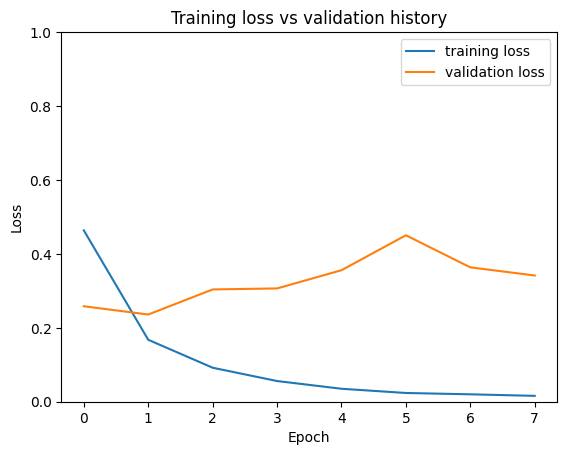

In [27]:
plt.plot(history['train_loss'], label='training loss')
plt.plot(history['val_loss'], label='validation loss')

plt.title('Training loss vs validation history')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.ylim([0, 1]);

In [28]:
model = ClassifierModel()

In [29]:
model_path = f"/kaggle/working/attention_on_bert_model.bin"
model.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [30]:
model.to(config.DEVICE)

ClassifierModel(
  (model): ElectraModel(
    (embeddings): ElectraEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): ElectraEncoder(
      (layer): ModuleList(
        (0-11): 12 x ElectraLayer(
          (attention): ElectraAttention(
            (self): ElectraSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ElectraSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), ep

In [31]:
# test_data = pd.read_csv("hf://datasets/kcrl/Gadet_Review_Dataset/" + splits["test"])

In [32]:
test_data.head()

,Reviews,category,Label,Length,Word Count
3436,কনডম কিনে খুব অনুতপ্ত। নকল মাল 😔😔 দাম আর কোয়া...,adult_items,0,63,13
2492,ওয়াটার ব্যাগ অরিজিনাল মনে হচ্ছে। অন্যরা নিতে ...,medical_kits,3,93,14
4179,বেস কয়েক টা পণ্য সামগ্রিই কিনেছি এর মধ্যে থার্...,medical_kits,1,95,18
1282,চমৎকার একটি প্রোডাক্ট। খুব উন্নত মানের প্রোডাক...,body_fitness,4,93,16
8862,"আমি ঠিক বলতে পারছি না কেন এমন হচ্ছে, মূলত মেডি...",medicines,1,79,15


In [33]:
test_dataset = ClassifierDataset(test_data, tokenizer)

In [34]:
from torch.utils.data import DataLoader
test_dataloader = DataLoader(
    test_dataset, batch_size=64, collate_fn=data_collator
)

In [35]:
model.eval()
pred = []
for batch in test_dataloader:
    batch = {k: v.to(config.DEVICE) for k, v in batch.items()}
    with torch.no_grad():
        outputs = model(input_ids = batch["input_ids"],attention_mask = batch["attention_mask"])
        batch_preds = torch.argmax(outputs, dim=-1)
        pred.extend(batch_preds.cpu().numpy().tolist()) 

In [36]:
y_true = test_data.Label.values
y_pred = pred

In [37]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print(confusion_matrix(y_true, y_pred))

[[419  19   2   0   0]
 [ 10 285  18   0   0]
 [  2  32 256  14   1]
 [  0   0  25 370   3]
 [  0   0   1   6 441]]


In [38]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score
)

# Print the classification report
print("Classification Report:\n", classification_report(y_true, y_pred))

# Print the confusion matrix
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

# Calculate individual metrics for weighted and macro averages
weighted_f1 = f1_score(y_true, y_pred, average='weighted')
macro_f1 = f1_score(y_true, y_pred, average='macro')

weighted_precision = precision_score(y_true, y_pred, average='weighted')
macro_precision = precision_score(y_true, y_pred, average='macro')

weighted_recall = recall_score(y_true, y_pred, average='weighted')
macro_recall = recall_score(y_true, y_pred, average='macro')

accuracy = accuracy_score(y_true, y_pred)

print("Model: Attention on BanglaBERT (Seed: 1)")

# Print metrics
print("Weighted F1 Score:", weighted_f1)
print("Macro F1 Score:", macro_f1)
print("Weighted Precision:", weighted_precision)
print("Macro Precision:", macro_precision)
print("Weighted Recall:", weighted_recall)
print("Macro Recall:", macro_recall)
print("Accuracy:", accuracy)

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96       440
           1       0.85      0.91      0.88       313
           2       0.85      0.84      0.84       305
           3       0.95      0.93      0.94       398
           4       0.99      0.98      0.99       448

    accuracy                           0.93      1904
   macro avg       0.92      0.92      0.92      1904
weighted avg       0.93      0.93      0.93      1904

Confusion Matrix:
 [[419  19   2   0   0]
 [ 10 285  18   0   0]
 [  2  32 256  14   1]
 [  0   0  25 370   3]
 [  0   0   1   6 441]]
Model: Attention on BanglaBERT (Seed: 1)
Weighted F1 Score: 0.9305317538052018
Macro F1 Score: 0.9221295268495876
Weighted Precision: 0.9313793671414875
Macro Precision: 0.9215566724428795
Weighted Recall: 0.9301470588235294
Macro Recall: 0.9232366723528511
Accuracy: 0.9301470588235294


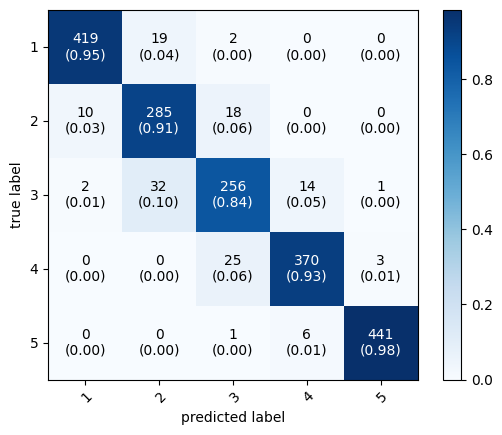

In [39]:
import torch
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix
from torchmetrics import ConfusionMatrix
y_pred = torch.tensor(y_pred)
y_true = torch.tensor(y_true)

cmat = ConfusionMatrix(task="multiclass", num_classes = 5)
confusion_matrix = cmat(y_pred, y_true)

fig, ax = plot_confusion_matrix(conf_mat=confusion_matrix.cpu().numpy(),
                                class_names=[1, 2, 3, 4, 5],
                                show_normed=True,
                                colorbar=True)

# Rotate the x-axis labels
plt.xticks(rotation=45, ha="right", rotation_mode="anchor")

# Show the plot
plt.show()